In [2]:
import pandas as pd

## Task 1 - Data Loading & Exploration

### Loading the CSV file using Pandas

In [3]:
df = pd.read_csv('Housing.csv')

### Displaying first 10 rows

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


### Checking number of rows and columns

In [5]:
df.shape

(545, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


- Price is the target column and the remaining 12 columns are the features

### Checking for missing values

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

- There are no null values in any column

## Task 2 - Data Cleaning

### Checking for duplicate rows

In [8]:
df.duplicated().sum()

0

- There are no duplicate rows

### Converting categorical columns into numerical form using one-hot encoding

In [9]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [10]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse = False, drop='first')
df_encoded = ohe.fit_transform(df[cat_cols])
print(df_encoded)

[[1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 1. ... 1. 1. 0.]
 ...
 [1. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 1.]]


In [11]:
feature_names = ohe.get_feature_names_out()
df_encoded = pd.DataFrame(df_encoded, columns = feature_names)

In [12]:
num_cols = [col for col in df.select_dtypes(include=['int64']).columns if col!='price']
print(num_cols)
num_df = df[num_cols]

['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


In [13]:
X = pd.concat([num_df.reset_index(drop=True), df_encoded.reset_index(drop=True)], axis=1)
y = df['price']

In [14]:
X.dtypes

area                                 int64
bedrooms                             int64
bathrooms                            int64
stories                              int64
parking                              int64
mainroad_yes                       float64
guestroom_yes                      float64
basement_yes                       float64
hotwaterheating_yes                float64
airconditioning_yes                float64
prefarea_yes                       float64
furnishingstatus_semi-furnished    float64
furnishingstatus_unfurnished       float64
dtype: object

#### Distibution of House Prices

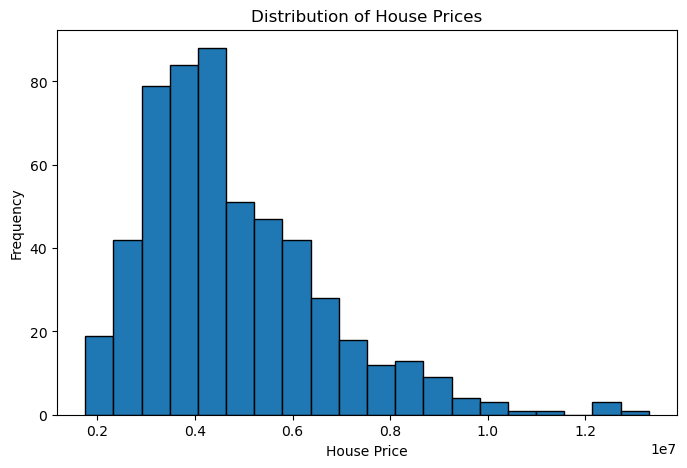

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['price'],bins=20,edgecolor='black')

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

### Checking for the meaningful values

#### 1. Pearson Correlation

In [16]:
analysis_df = X.copy()
analysis_df['price'] = y
corr = analysis_df.corr()
corr['price'].sort_values(ascending=False)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

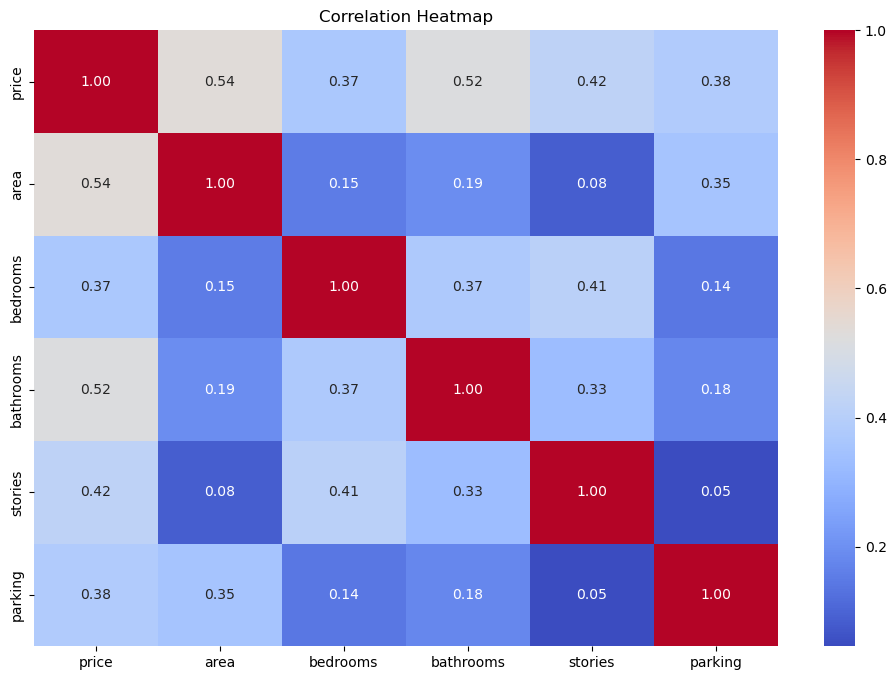

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")

plt.show()

#### 2. Mutual Information

In [18]:
from sklearn.feature_selection import mutual_info_regression

mi_score = mutual_info_regression(X,y,random_state=42)

In [19]:
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score' : mi_score})
mi_df = mi_df.sort_values(by="MI Score", ascending=False)
print(mi_df)

                            Feature  MI Score
0                              area  0.283384
4                           parking  0.147656
2                         bathrooms  0.141955
9               airconditioning_yes  0.110157
3                           stories  0.101973
1                          bedrooms  0.098010
6                     guestroom_yes  0.097859
12     furnishingstatus_unfurnished  0.091031
5                      mainroad_yes  0.078825
10                     prefarea_yes  0.069422
7                      basement_yes  0.046633
11  furnishingstatus_semi-furnished  0.045338
8               hotwaterheating_yes  0.010955


#### 3. Random Forest Feature Importance

In [20]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X,y)

RandomForestRegressor(random_state=42)

In [21]:
importance_df = pd.DataFrame({"Feature":X.columns, "Importance":rf.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)

                            Feature  Importance
0                              area    0.466788
2                         bathrooms    0.154835
4                           parking    0.061691
3                           stories    0.055426
9               airconditioning_yes    0.054924
1                          bedrooms    0.042237
12     furnishingstatus_unfurnished    0.039007
10                     prefarea_yes    0.034931
7                      basement_yes    0.030676
6                     guestroom_yes    0.018325
8               hotwaterheating_yes    0.016329
11  furnishingstatus_semi-furnished    0.015126
5                      mainroad_yes    0.009704


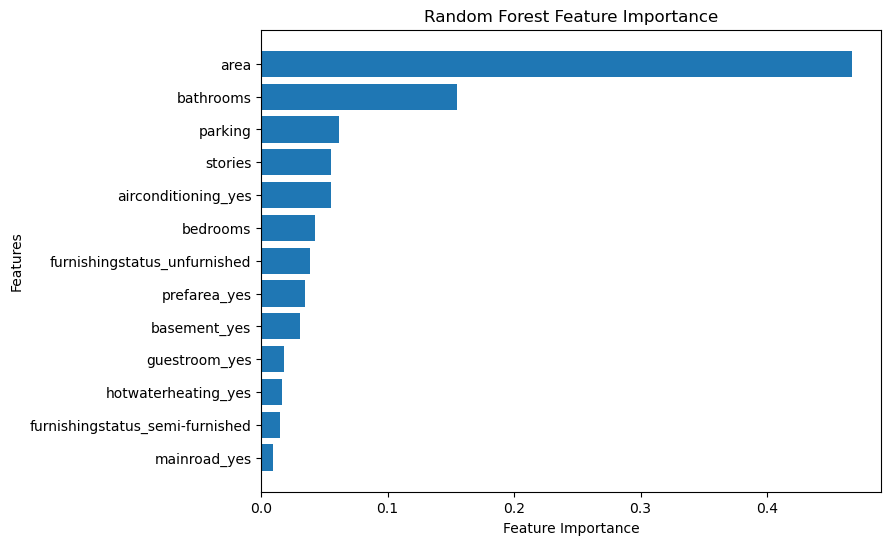

In [22]:
importance_df = importance_df.sort_values(by="Importance",ascending=False)
plt.figure(figsize=(8,6))
plt.barh(importance_df["Feature"],importance_df["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

- Multiple feature selection technioques were applied to evealuate the importanve of each feature. Since every feature exhibited some level of predictive contribution, no feature is removed from the dataset.

## Task 3 - Model Building

### Splitting the data to train and test sets

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [24]:
X_train_rf = X_train.copy()
X_test_rf = X_test.copy()

X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols] = scaler.transform(X_test_lr[num_cols])

### Training a Linear Regression model

In [26]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_lr, y_train)

LinearRegression()

In [27]:
y_pred = lr.predict(X_test_lr)

### Evaluating using MAE, RMSE, R2 Score

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE: ",mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

MAE:  970043.4039201642
RMSE:  1324506.9600914405
R2 Score:  0.6529242642153175


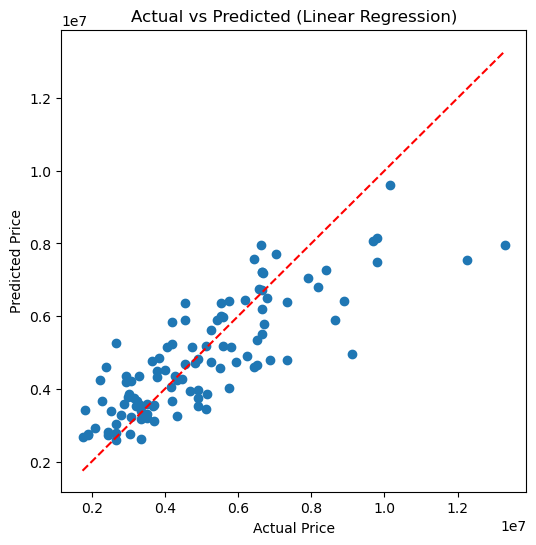

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

### Training Random Forest Regressor

In [30]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators = 100, random_state=42)
rf.fit(X_train_rf, y_train)
y_pred_rf = rf.predict(X_test_rf)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("MAE: ",mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

MAE:  1021546.0353211008
RMSE:  1400565.9728553821
R2 Score:  0.611918531405699


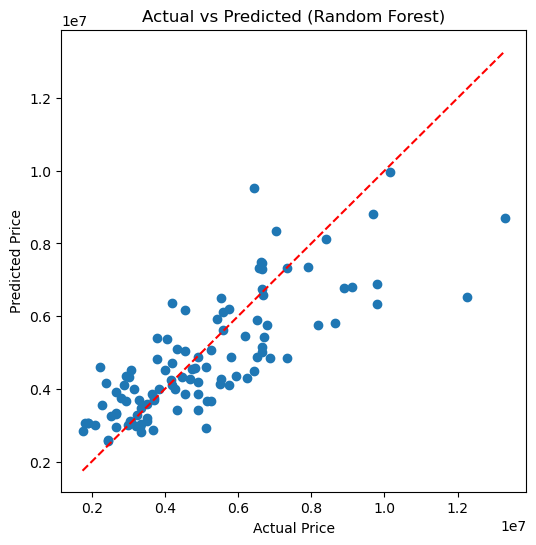

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Random Forest)")

plt.show()

In [33]:
train_r2 = rf.score(X_train, y_train)
test_r2 = rf.score(X_test, y_test)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training R²: 0.9498833271635604
Testing R² : 0.611918531405699


- The random forest model is overfitting

In [143]:
print("Random Forest")
print("Train:", rf.score(X_train_rf, y_train))
print("Test :", rf.score(X_test_rf, y_test))

print()

print("Linear Regression")
print("Train:", lr.score(X_train_lr, y_train))
print("Test :", lr.score(X_test_lr, y_test))

Random Forest
Train: 0.9498833271635604
Test : 0.611918531405699

Linear Regression
Train: 0.6859438988560158
Test : 0.6529242642153175


## Task 5 - Insights & Summary

- The analysis shows that area, bathrooms, stories, parking and air conditionaing were the most influential features affecting the house prices.
- The Linear Regression model achieved an R2 score of 0.653 indicating that it could explain approximately 65% of the variation in house prices, which represents a reasonably good predictive performance.
- When compared with the Random Forest Regressor, Linear Regression performed better, achieving a higher R² score and lower MAE and RMSE values.
- Some features, such as hot water heating had very little influence on house prices.
- Based on these findings, a real estate business should focus on properties with larger areas, more bathrooms, additional stories, parking facilities and air conditioning as these features are more strongly associated with higher property values.